# 19 - TinyPhase + InvA before versus after coil combination

This experiment compares two placements of the same TinyPhase + InvA method: (1) directly on the stored complex 2-D `spen_original`, treated as one virtual coil, and (2) on the original four complex receiver coils before adaptive coil combination.

`traditional_recon` is loaded only for the second display panel and post-reconstruction metrics. `calc_inva_params` supplies the fixed `InvA`, `OddInvA`, and `EvenInvA` operators. No saved phase map or phase-corrected signal is used.

The comparison isolates an ordering question: `coil combine -> TinyPhase/InvA` versus `TinyPhase/InvA per coil -> coil combine`. The single-image branch requires the complex MAT variable; a magnitude PNG alone has discarded the phase needed by TinyPhase.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import torch
import torch.nn as nn


def find_workspace_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'data' / 'mat').is_dir() and (candidate / 'spenpy' / 'spenpy').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from spen_recons or one of its subdirectories.')


ROOT = find_workspace_root()
SPENPY_ROOT = ROOT / 'spenpy'
if str(SPENPY_ROOT) not in sys.path:
    sys.path.insert(0, str(SPENPY_ROOT))

from spenpy.core import calcInvA
from spenpy.recon.spen_recon import orient_pv360_spen_image
from spenpy.utils.coil_combine import coil_combine

plt.rcParams['figure.dpi'] = 120
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('workspace:', ROOT)
print('device   :', device)

workspace: /home/data2/chk/workspace/2026/08/14/spen_recons
device   : cuda


## Load the combined image, four-coil signal, and InvA metadata

The saved `spen_original` is already in display orientation, so the orientation helper converts it back before applying the operators. The saved four-coil ROFFT signal is already in operator orientation.

In [2]:
MAT_PATH = ROOT / 'data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat'
mat = scipy.io.loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)

# Input for the virtual-single-coil branch.
spen_original = np.asarray(mat['spen_original'])

# Input for the four-coil branch: [PE, RO, image, coil].
rofft_np = np.asarray(mat['spen_original_signal_rofft'])
if rofft_np.ndim == 3:
    rofft_np = rofft_np[:, :, None, :]

# Display-only comparator; never passed into TinyPhase or InvA.
traditional_recon = np.asarray(mat['traditional_recon'])

# Acquisition/operator metadata, needed to construct the fixed matrices.
params = mat['calc_inva_params']

if spen_original.ndim != 2 or not np.iscomplexobj(spen_original):
    raise ValueError('Demo 19 requires a complex 2-D spen_original, not a magnitude PNG.')
if spen_original.shape[0] % 2:
    raise ValueError('The PE dimension must be even for odd/even phase fitting.')
if rofft_np.ndim != 4 or rofft_np.shape[-1] != 4 or not np.iscomplexobj(rofft_np):
    raise ValueError('The four-coil branch requires complex [PE, RO, image, 4] ROFFT data.')
if tuple(rofft_np.shape[:2]) != tuple(spen_original.shape):
    raise ValueError('spen_original and four-coil ROFFT spatial shapes must match.')


def build_inva(args):
    args = torch.as_tensor(args, dtype=torch.float64, device=device).flatten()
    inv_a, _ = calcInvA(
        args[0], args[1], int(args[2].item()), args[3],
        int(args[4].item()), args[5], args[6],
    )
    return inv_a.to(device=device, dtype=torch.complex64)


InvA = build_inva(params.full_args)
OddInvA = build_inva(params.odd_args)
EvenInvA = build_inva(params.even_args)

# Undo the stored 180-degree display orientation for the single-image branch.
operator_image = np.ascontiguousarray(orient_pv360_spen_image(spen_original).copy())
measurement = torch.as_tensor(operator_image, dtype=torch.complex64, device=device)
coil_measurement = torch.as_tensor(np.ascontiguousarray(rofft_np), dtype=torch.complex64, device=device)

print('MAT path               :', MAT_PATH)
print('single-image input key  : spen_original')
print('four-coil input key     : spen_original_signal_rofft')
print('display-only key       : traditional_recon')
print('single-image shape      :', tuple(measurement.shape), measurement.dtype)
print('four-coil shape         :', tuple(coil_measurement.shape), coil_measurement.dtype)
print('InvA / odd / even      :', tuple(InvA.shape), tuple(OddInvA.shape), tuple(EvenInvA.shape))

MAT path               : /home/data2/chk/workspace/2026/08/14/spen_recons/data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat
single-image input key  : spen_original
four-coil input key     : spen_original_signal_rofft
display-only key       : traditional_recon
single-image shape      : (96, 96) torch.complex64
four-coil shape         : (96, 96, 1, 4) torch.complex64
InvA / odd / even      : (96, 96) (48, 48) (48, 48)


## Apply the same TinyPhase fit to one virtual coil or four real coils

For either input, odd and even PE rows are separately reconstructed with the half-size InvA matrices. The four-coil branch forms its phase evidence by summing the odd/even complex cross-products over receivers; the single-image branch has one component.

In [3]:
class TinyPhaseNet(nn.Module):
    def __init__(self, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, coords):
        return self.net(coords).squeeze(-1)


def wrap_phase(value):
    return torch.atan2(torch.sin(value), torch.cos(value))


def normalized_coords(height, width):
    y = torch.linspace(-1.0, 1.0, height, device=device)
    x = torch.linspace(-1.0, 1.0, width, device=device)
    yy, xx = torch.meshgrid(y, x, indexing='ij')
    return torch.stack([xx, yy], dim=-1).reshape(-1, 2)


def apply_pe_matrix(matrix, data):
    return torch.einsum('pq,q...->p...', matrix, data)


def phase_components(data):
    odd = apply_pe_matrix(OddInvA, data[0::2])
    even = apply_pe_matrix(EvenInvA, data[1::2])
    if data.ndim == 2:
        return odd.unsqueeze(-1), even.unsqueeze(-1)
    if data.ndim == 4 and data.shape[2] == 1:
        return odd[:, :, 0, :], even[:, :, 0, :]
    raise ValueError('Expected [PE, RO] or [PE, RO, 1, coil] complex data.')


def fit_tiny_phase(data, steps=500, lr=3e-2, smooth_weight=2e-3):
    odd, even = phase_components(data)
    cross = torch.sum(even * torch.conj(odd), dim=-1)
    raw_phase = torch.angle(cross).float()

    odd_mag = torch.sqrt(torch.sum(odd.abs().square(), dim=-1))
    even_mag = torch.sqrt(torch.sum(even.abs().square(), dim=-1))
    mag_std = torch.std(even_mag - odd_mag)
    mask = (odd_mag > 2.0 * mag_std) & (even_mag > 2.0 * mag_std) & torch.isfinite(raw_phase)
    if not torch.any(mask):
        raise RuntimeError('No reliable pixels remain for phase fitting.')
    cutoff = torch.quantile(cross.abs()[mask], 0.20)
    mask = mask & (cross.abs() >= cutoff)

    weights = mask.float() * torch.minimum(odd_mag, even_mag).float()
    weights = weights / weights.max().clamp_min(1e-8)
    height, width = raw_phase.shape
    coords = normalized_coords(height, width)
    torch.manual_seed(0)
    model = TinyPhaseNet(hidden=8).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    for _ in range(steps + 1):
        optimizer.zero_grad(set_to_none=True)
        phase = model(coords).reshape(height, width)
        corrected_even = even * torch.exp(-1j * phase[:, :, None])
        corrected_cross = torch.sum(corrected_even * torch.conj(odd), dim=-1)
        alignment = 1.0 - torch.sum(
            weights * corrected_cross.real / corrected_cross.abs().clamp_min(1e-8)
        ) / weights.sum().clamp_min(1e-8)
        smooth = (
            wrap_phase(phase[:, 1:] - phase[:, :-1]).square().mean()
            + wrap_phase(phase[1:] - phase[:-1]).square().mean()
        )
        (alignment + smooth_weight * smooth).backward()
        optimizer.step()

    phase = model(coords).reshape(height, width).detach()
    corrected_even = even * torch.exp(-1j * phase[:, :, None])
    residual_phase = torch.angle(torch.sum(corrected_even * torch.conj(odd), dim=-1)).float()
    return phase, raw_phase, residual_phase, mask


In [4]:
def synchronize():
    if device.type == 'cuda':
        torch.cuda.synchronize()


def apply_even_phase(data, phase):
    corrected = data.clone()
    phase_factor = torch.exp(-1j * phase)
    if data.ndim == 2:
        corrected[1::2] *= phase_factor
    else:
        corrected[1::2] *= phase_factor[:, :, None, None]
    return corrected


def phase_summary(label, raw, residual, mask, elapsed):
    print(label)
    print(f'  elapsed                       : {elapsed:.2f} s')
    print(f'  phase mask fraction           : {mask.float().mean().item():.3f}')
    print(f'  masked |phase| before         : {raw[mask].abs().mean().item():.4f} rad')
    print(f'  masked |phase residual| after : {residual[mask].abs().mean().item():.4f} rad')


# Branch A: already-combined spen_original, treated as one virtual coil.
synchronize()
start = time.perf_counter()
single_phase, single_raw_phase, single_phase_residual, single_phase_mask = fit_tiny_phase(measurement)
single_corrected = apply_even_phase(measurement, single_phase)
single_recon_operator = apply_pe_matrix(InvA, single_corrected)
single_recon = np.ascontiguousarray(
    orient_pv360_spen_image(single_recon_operator.detach().cpu().numpy()).copy()
)
synchronize()
single_elapsed = time.perf_counter() - start

# Branch B: phase correction and InvA on four coils, then adaptive combination.
synchronize()
start = time.perf_counter()
coil_phase, coil_raw_phase, coil_phase_residual, coil_phase_mask = fit_tiny_phase(coil_measurement)
coil_corrected = apply_even_phase(coil_measurement, coil_phase)
coil_recon = apply_pe_matrix(InvA, coil_corrected)
four_coil_recon_operator = coil_combine(coil_recon[:, :, 0, :])
four_coil_recon = np.ascontiguousarray(
    orient_pv360_spen_image(four_coil_recon_operator.detach().cpu().numpy()).copy()
)
synchronize()
coil_elapsed = time.perf_counter() - start

phase_summary('Combined-image branch', single_raw_phase, single_phase_residual, single_phase_mask, single_elapsed)
phase_summary('Four-coil branch', coil_raw_phase, coil_phase_residual, coil_phase_mask, coil_elapsed)

Combined-image branch
  elapsed                       : 7.05 s
  phase mask fraction           : 0.226
  masked |phase| before         : 1.0944 rad
  masked |phase residual| after : 0.1765 rad
Four-coil branch
  elapsed                       : 11.08 s
  phase mask fraction           : 0.280
  masked |phase| before         : 1.0848 rad
  masked |phase residual| after : 0.2240 rad


## Four-panel result

The first two panels are references. The third reconstructs from the first panel's underlying complex combined image; the fourth reconstructs the four receiver coils before adaptive combination.

combined-image vs traditional: correlation=0.9664, NRMSE=0.2162
four-coil     vs traditional: correlation=0.9812, NRMSE=0.1597
(Traditional is used only for these post-reconstruction diagnostics.)


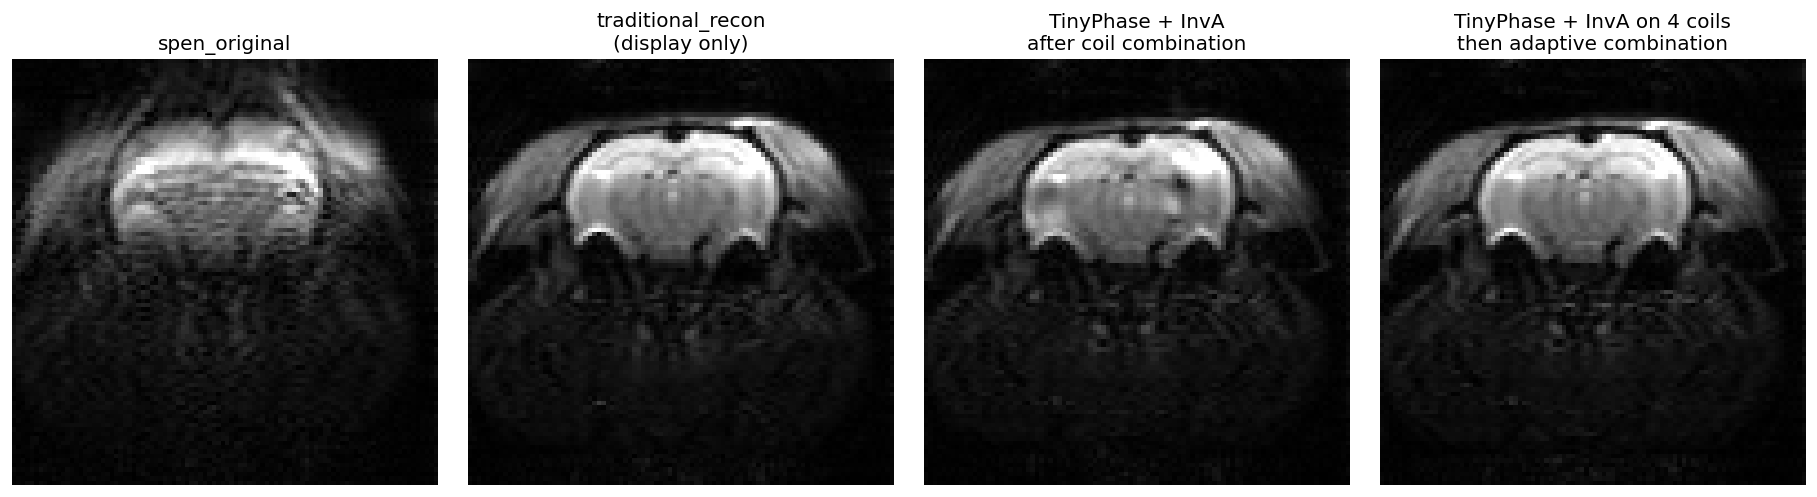

In [5]:
def robust_abs01(value, percentile=99.5):
    image = np.abs(np.asarray(value)).astype(np.float32)
    positive = image[image > 0]
    scale = np.percentile(positive, percentile) if positive.size else 1.0
    return np.clip(image / max(float(scale), 1e-8), 0.0, 1.0)


original_display = robust_abs01(spen_original)
traditional_display = robust_abs01(traditional_recon)
single_display = robust_abs01(single_recon)
four_coil_display = robust_abs01(four_coil_recon)

def display_metrics(estimate, reference):
    correlation = np.corrcoef(estimate.ravel(), reference.ravel())[0, 1]
    nrmse = np.linalg.norm(estimate - reference) / np.linalg.norm(reference)
    return correlation, nrmse


single_correlation, single_nrmse = display_metrics(single_display, traditional_display)
coil_correlation, coil_nrmse = display_metrics(four_coil_display, traditional_display)
print(f'combined-image vs traditional: correlation={single_correlation:.4f}, NRMSE={single_nrmse:.4f}')
print(f'four-coil     vs traditional: correlation={coil_correlation:.4f}, NRMSE={coil_nrmse:.4f}')
print('(Traditional is used only for these post-reconstruction diagnostics.)')

fig, ax = plt.subplots(1, 4, figsize=(15.2, 4.0), constrained_layout=True)
for axis, image, title in [
    (ax[0], original_display, 'spen_original'),
    (ax[1], traditional_display, 'traditional_recon\n(display only)'),
    (ax[2], single_display, 'TinyPhase + InvA\nafter coil combination'),
    (ax[3], four_coil_display, 'TinyPhase + InvA on 4 coils\nthen adaptive combination'),
]:
    axis.imshow(image, cmap='gray', vmin=0.0, vmax=1.0)
    axis.set_title(title)
    axis.axis('off')

plt.show()

## Interpretation

The third panel tests a lightweight combined-image approximation. The fourth preserves receiver-specific complex information until after TinyPhase and InvA, matching the conventional ordering more closely. Neither branch uses `traditional_recon` as a fitting target.